In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from keras.datasets import mnist
from keras.utils import to_categorical, set_random_seed
from keras import layers, models
from random import seed
from scipy.ndimage import gaussian_filter
import plotly.graph_objects as go

2025-12-14 13:01:53.296675: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-14 13:01:53.374389: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-14 13:01:55.667222: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


#### Tworzymy model sieci splotowej do rozpoznawania cyfr z zestawu danych mnist

In [2]:
cnn = models.Sequential(
        [layers.Input((28, 28, 1)),
         layers.Conv2D(28, (3, 3)),
         layers.MaxPooling2D((2, 2)),
         layers.Conv2D(28, (3, 3)),
         layers.MaxPooling2D((2, 2)),
         layers.Conv2D(28, (3, 3)),
         layers.Flatten(),
         layers.Dense(50, activation='relu'),
         layers.Dense(50, activation='relu'),
         layers.Dense(10, activation='softmax')
        ]
    )

cnn.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

2025-12-14 13:01:58.679220: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
def mnist_load():
    (X_train, y_train), (X_test, y_test) = mnist.load_data()
    X_train_r = X_train.astype('float32')
    X_test_r = X_test.astype('float32')
    X_train_r /= 255                   
    X_test_r /= 255
    return (X_train_r, y_train), (X_test_r, y_test)

set_random_seed(123)
liczba_klas=10
(X_train, y_train), (X_test, y_test) = mnist_load()
indeksy = {i: list(*np.where(y_train==i)) for i in range(10)}
y_test = to_categorical(y_test, liczba_klas)
y_train_cat = to_categorical(y_train, liczba_klas)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [4]:
cnn.fit(X_train, y_train_cat, validation_data=(X_test,y_test), epochs=10, batch_size=200)
Y_pred=np.argmax(cnn.predict(X_test),axis=1)
y_real=np.argmax(y_test, axis=1)

Epoch 1/10


2025-12-14 13:02:16.254448: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 188160000 exceeds 10% of free system memory.


  2/300 ━━━━━━━━━━━━━━━━━━━━ 30s 104ms/step - accuracy: 0.1325 - loss: 2.3028

2025-12-14 13:02:19.875735: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 23539824 exceeds 10% of free system memory.
2025-12-14 13:02:19.876674: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 23539824 exceeds 10% of free system memory.
2025-12-14 13:02:19.969614: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 23539824 exceeds 10% of free system memory.
2025-12-14 13:02:19.969873: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 23539824 exceeds 10% of free system memory.


300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 86ms/step - accuracy: 0.8767 - loss: 0.4129 - val_accuracy: 0.9578 - val_loss: 0.1361
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 31s 104ms/step - accuracy: 0.9657 - loss: 0.1161 - val_accuracy: 0.9771 - val_loss: 0.0776
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 24s 80ms/step - accuracy: 0.9765 - loss: 0.0780 - val_accuracy: 0.9790 - val_loss: 0.0702
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 25s 83ms/step - accuracy: 0.9815 - loss: 0.0602 - val_accuracy: 0.9823 - val_loss: 0.0593
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 37s 71ms/step - accuracy: 0.9850 - loss: 0.0497 - val_accuracy: 0.9846 - val_loss: 0.0485
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 25s 84ms/step - accuracy: 0.9870 - loss: 0.0422 - val_accuracy: 0.9864 - val_loss: 0.0441
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 28s 93ms/step - accuracy: 0.9888 - loss: 0.0369 - val_accuracy: 0.9873 - val_loss: 0.0413
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 38s 84ms/step - accuracy: 0.9903 - loss: 0.0325 - val_accura

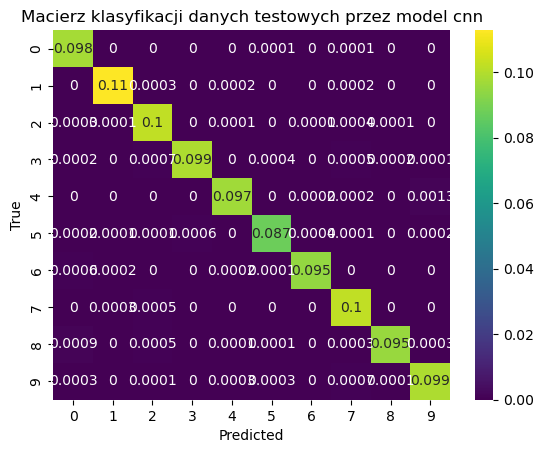

In [5]:
sns.heatmap(metrics.confusion_matrix(y_real, Y_pred, normalize='all'), annot=True, cmap='viridis')
plt.title('Macierz klasyfikacji danych testowych przez model cnn')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

Modyfikujemy zestaw danych uczących, nakładając filtr gaussowski na każdy obrazek zera (czyli rozmywawey każde zero). Dane testowe pozostawiamy jednak niezmienione.

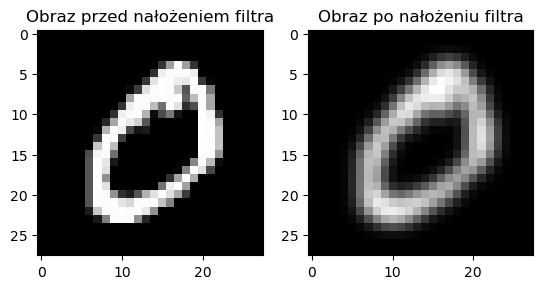

In [6]:
X_trainb=np.copy(X_train)
for i in indeksy[0]:
    X_trainb[i]=gaussian_filter(X_train[i], sigma=1)
plt.subplot(1,2,1)
plt.imshow(X_train[indeksy[0][0]], cmap='gray', interpolation='none')
plt.title('Obraz przed nałożeniem filtra')
plt.subplot(1,2,2)
plt.imshow(X_trainb[indeksy[0][0]], cmap='gray', interpolation='none')
plt.title('Obraz po nałożeniu filtra')
plt.show()

Model (taki sam jak wcześniej) uczymy na zmodyfikowanych danych uczących.

In [7]:
n_epochs=10

cnn1 = models.Sequential(
        [layers.Input((28, 28, 1)),
         layers.Conv2D(28, (3, 3)),
         layers.MaxPooling2D((2, 2)),
         layers.Conv2D(28, (3, 3)),
         layers.MaxPooling2D((2, 2)),
         layers.Conv2D(28, (3, 3)),
         layers.Flatten(),
         layers.Dense(50, activation='relu'),
         layers.Dense(50, activation='relu'),
         layers.Dense(10, activation='softmax')
        ]
    )
cnn1.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
hist=cnn1.fit(X_trainb, y_train_cat, validation_data=(X_test,y_test), epochs=n_epochs, batch_size=200)
Y_pred=np.argmax(cnn1.predict(X_test),axis=1)
accuracy_train = hist.history['accuracy']
accuracy_val = hist.history['val_accuracy']
loss_train = hist.history['loss']
loss_val = hist.history['val_loss']

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.8813 - loss: 0.3923 - val_accuracy: 0.9626 - val_loss: 0.1221
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9711 - loss: 0.0954 - val_accuracy: 0.9609 - val_loss: 0.1378
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9801 - loss: 0.0657 - val_accuracy: 0.9593 - val_loss: 0.1590
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9844 - loss: 0.0503 - val_accuracy: 0.9472 - val_loss: 0.2148
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9875 - loss: 0.0417 - val_accuracy: 0.9435 - val_loss: 0.2485
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9895 - loss: 0.0356 - val_accuracy: 0.9379 - val_loss: 0.3034
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9906 - loss: 0.0310 - val_accuracy: 0.9274 - val_loss: 0.3770
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9913 - loss: 0.0281 - val_accu

In [16]:
x=list(range(1,n_epochs+1))
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=x,
               y=accuracy_train,
               name="Accuracy train",
               line=dict(color="purple")))
fig.add_trace(
    go.Scatter(x=x,
               y=accuracy_val,
               name="Accuracy val",
               line=dict(color="red")))
fig.update_layout(
    xaxis=dict(title=dict(text="Epoch")),
    yaxis=dict(title=dict(text="Accuracy")),
    updatemenus=[
        dict(
            active=0,
            buttons=list([
                dict(label="Accuracy train",
                     method="update",
                     args=[{"visible": [True, False]}]),
                dict(label="Accuracy val",
                     method="update",
                     args=[{"visible": [False, True]}]),
                dict(label="Both",
                     method="update",
                     args=[{"visible": [True, True]}])
            ]),
        )
    ])

fig.update_layout(title_text="Przebieg procesu uczenia")

Jak widać z przebiegu uczenia, mamy do czynienia z przetrenowaniem (overfitting) modelu. Dokładność dla danych walidacyjnych jest znacznie niższa niż dla danych treningowych. Sprawdźmy jak wygląda dokładność klasyfikacji poszczególnych cyfr, analizując macierz klasyfikacji (confusion matrix).

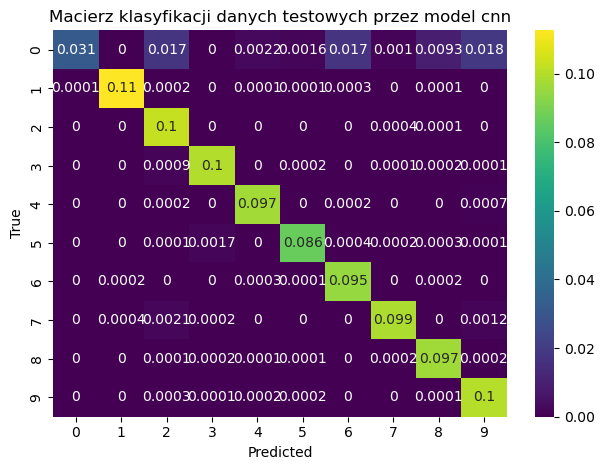

In [9]:
sns.heatmap(metrics.confusion_matrix(y_real, Y_pred, normalize='all'), annot=True, cmap='viridis')
plt.title('Macierz klasyfikacji danych testowych przez model cnn')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

Tworzymy nowy model CNN z takimi samymi warstwami lecz dodając dropout po każdej warstwie (dla warstw splotowych ustalamy prawd. wygaszenia p=0.2, a dla warstw gęstych p=0.3).

In [10]:
cnn2 = models.Sequential(
        [layers.Input((28, 28, 1)),
         layers.Conv2D(28, (3, 3)),
         layers.Dropout(0.2),
         layers.MaxPooling2D((2, 2)),
         layers.Conv2D(28, (3, 3)),
         layers.Dropout(0.2),
         layers.MaxPooling2D((2, 2)),
         layers.Conv2D(28, (3, 3)),
         layers.Dropout(0.2),
         layers.Flatten(),
         layers.Dense(50, activation='relu'),
         layers.Dropout(0.3),
         layers.Dense(50, activation='relu'),
         layers.Dropout(0.3),
         layers.Dense(10, activation='softmax')
        ]
    )
cnn2.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [11]:
histb=cnn2.fit(X_trainb, y_train_cat, validation_data=(X_test,y_test), epochs=n_epochs, batch_size=200)
accuracy_trainb = histb.history['accuracy']
accuracy_valb = histb.history['val_accuracy']
loss_trainb = histb.history['loss']
loss_valb = histb.history['val_loss']

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.7740 - loss: 0.6862 - val_accuracy: 0.9587 - val_loss: 0.1497
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9341 - loss: 0.2228 - val_accuracy: 0.9709 - val_loss: 0.1002
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9531 - loss: 0.1602 - val_accuracy: 0.9659 - val_loss: 0.1181
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.9617 - loss: 0.1370 - val_accuracy: 0.9723 - val_loss: 0.1008
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9674 - loss: 0.1159 - val_accuracy: 0.9715 - val_loss: 0.1050
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9682 - loss: 0.1097 - val_accuracy: 0.9705 - val_loss: 0.1060
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9722 - loss: 0.0983 - val_accuracy: 0.9737 - val_loss: 0.0948
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.9733 - loss: 0.0939 - val_accu

In [17]:
x=list(range(1,n_epochs+1))
fig = go.Figure()

fig.add_trace(
    go.Scatter(x=x,
               y=accuracy_trainb,
               name="Accuracy train",
               line=dict(color="purple")))
fig.add_trace(
    go.Scatter(x=x,
               y=accuracy_valb,
               name="Accuracy val",
               line=dict(color="red")))
fig.update_layout(
    xaxis=dict(title=dict(text="Epoch")),
    yaxis=dict(title=dict(text="Accuracy")),
    updatemenus=[
        dict(
            active=0,
            buttons=list([
                dict(label="Accuracy train",
                     method="update",
                     args=[{"visible": [True, False]}]),
                dict(label="Accuracy val",
                     method="update",
                     args=[{"visible": [False, True]}]),
                dict(label="Both",
                     method="update",
                     args=[{"visible": [True, True]}])
            ]),
        )
    ])

fig.update_layout(title_text="Przebieg procesu uczenia")

Patrząc na wykres dokładności klasyfikacji w przebiegu uczenia, możemy zauważyć wyeliminowanie problemu przetrenowania, kosztem jednak niedotrenowania (dokładność klasyfikacji danych uczących nieznacznie zmalała) - model musi dokonywać klasyfikacji na podstawie wykrywania większej liczby wzorców niż wcześeniej (bez dropoutu).

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


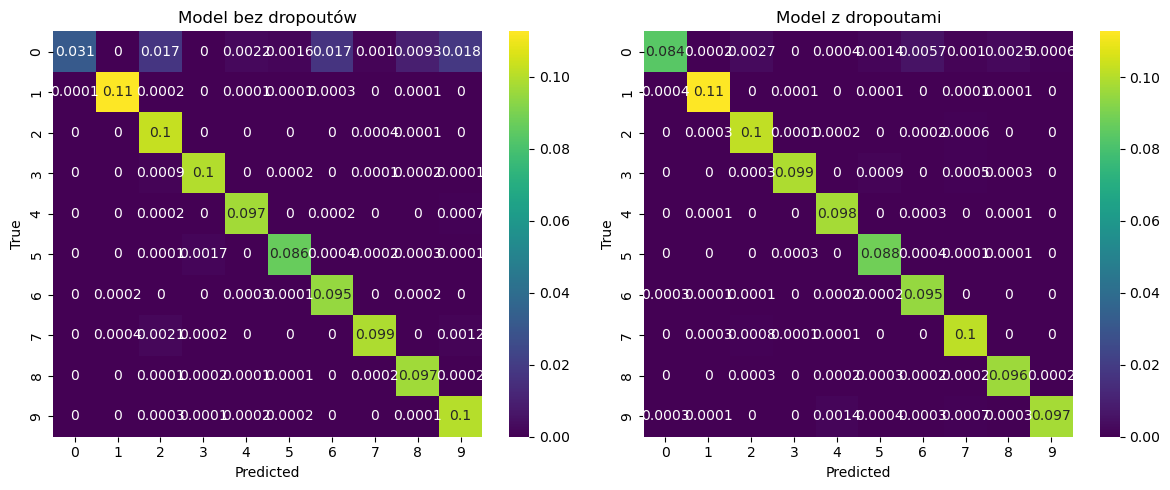

In [13]:
Y_predb=np.argmax(cnn2.predict(X_test),axis=1)
plt.rcParams["figure.figsize"] = (12,5)
plt.subplot(1,2,1)
sns.heatmap(metrics.confusion_matrix(y_real, Y_pred, normalize='all'), annot=True, cmap='viridis')
plt.title('Model bez dropoutów')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.subplot(1,2,2)
sns.heatmap(metrics.confusion_matrix(y_real, Y_predb, normalize='all'), annot=True, cmap='viridis')
plt.title('Model z dropoutami')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()